## Описание файла 
Скрипт представляет собой базовое решение (Baseline) для системы визуального поиска товаров: от предобработки данных и обучения нейросети с использованием метрического обучения (Metric Learning) до оценки качества поиска с помощью векторного индекса.

## Основные возможности Baseline

* **Подготовка данных**

  - Очистка датасета от полных дубликатов, конфликтующих меток и групп, в которых осталось менее 2 изображений, для повышения стабильности обучения.  
  - Разделение на обучающую, валидационную и тестовую выборки с использованием `GroupShuffleSplit` (гарантирует, что изображения одного товара не попадут в разные выборки одновременно).  

* **Архитектура модели и Loss-функция**

  - Использование предобученной модели `ResNet50` из библиотеки `timm` в качестве экстрактора признаков.  
  - Применение **ArcFace Loss** — функции потерь для метрического обучения, которая максимизирует расстояние между разными классами и минимизирует внутри одного класса.
  - Поддержка распределенного обучения (**DDP** — DistributedDataParallel) для ускорения процесса на нескольких GPU.

* **Валидация и метрики поиска**

  - Оценка модели через метрики поиска: **Recall@1** и **mAP@5**.  
  - Расчёт **Similarity Gap** — разницы между средней схожестью «своих» и «чужих» товаров для оценки качества разделения признаков.

* **Векторный поиск (FAISS)**

  - Построение эффективного индекса `FAISS` для быстрого нахождения ближайших соседей в пространстве эмбеддингов.  
  - Визуализация результатов: наглядное отображение запроса и найденных похожих товаров.

## Установка и зависимости

Для работы скрипта требуются следующие библиотеки:
* `torch` и `torchvision`
* `timm` (модели компьютерного зрения)
* `pytorch_metric_learning` (реализация ArcFace)
* `faiss-cpu` или `faiss-gpu` (для векторного поиска)
* `albumentations` (продвинутые аугментации)
* `pandas`, `numpy`, `opencv-python`, `matplotlib`, `scikit-learn`, `tqdm`.

## Инструкция по использованию

1. **Пути к данным:** По умолчанию скрипт ищет данные в `/kaggle/input/competitions/shopee-product-matching/`. Если вы запускаете код локально, измените `BASE_DIR` в классе `Config`.
2. **Конфигурация:** Все ключевые параметры (размер изображения, гиперпараметры ArcFace, размер батча, seed, learning rate) сосредоточены в классе `Config` в начале скрипта.
3. **Запуск:** Запустите ячейки ноутбука последовательно. Для обучения скрипт сгенерирует отдельный файл `train_baseline.py` и запустит его, чтобы использовать все доступные видеокарты (DDP).
4. **Результаты:** По завершении обучения скрипт сохранит веса лучшей модели (по метрике mAP@5) в файл `best_baseline_model.pth`, а историю обучения и метрики валидации — в файл `ddp_history.json`.

## Импорт библиотек и конфиг

In [1]:
import json
import os
import random
import subprocess
import sys
from typing import Dict, List, Tuple

import albumentations as A
import cv2
import faiss
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from albumentations.pytorch import ToTensorV2
from PIL import Image
from pytorch_metric_learning import losses
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

In [2]:
class Config:
    BASE_DIR = '/kaggle/input/competitions/shopee-product-matching/'
    CSV_PATH = f'{BASE_DIR}train.csv'
    IMAGE_DIR = f'{BASE_DIR}train_images/'
    DATASET_MEAN_COLOR = (192, 183, 178)  # mean-padding цвет
    IMG_SIZE = 336
    BATCH_SIZE = 128
    EPOCHS = 15
    LR = 1e-4
    WEIGHT_DECAY = 1e-4
    ARC_MARGIN = 28.6
    ARC_SCALE = 64.0
    SEED = 42
    TRAIN_SIZE = 0.70
    VAL_SIZE   = 0.15
    TEST_SIZE  = 0.15
    NUM_WORKERS = 4           
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    MASTER_ADDR = 'localhost'
    MASTER_PORT = '12355'

In [3]:
# Фиксируем все источники случайности для воспроизводимости
random.seed(Config.SEED)
np.random.seed(Config.SEED)
torch.manual_seed(Config.SEED)
A.core.composition.SEED = Config.SEED
if torch.cuda.is_available():
    torch.cuda.manual_seed(Config.SEED)

## Функции и классы

In [4]:
def preprocess_data(
    csv_path: str,
    image_dir: str,
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    random_state: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, int]:
    """
    Загружает и предобрабатывает данные Shopee.
    Этапы:
        1. Загрузка CSV и добавление полного пути к изображениям.
        2. Очистка данных:
           - удаление полных дубликатов (image_phash, label_group)
           - удаление строк с конфликтующими метками (один phash в разных группах)
           - удаление групп, в которых осталось менее 2 изображений
        3. Label Encoding для label_group.
        4. Разделение на train/val/test с сохранением целостности групп.
    """
    # Загрузка
    df = pd.read_csv(csv_path)
    df['image_path'] = df['image'].apply(lambda x: os.path.join(image_dir, x))
    
    # Очистка данных
    initial_len = len(df)
    # Удаляем точные дубликаты (одинаковые phash и группа)
    df = df.drop_duplicates(subset=['image_phash', 'label_group'], keep='first')
    print(f"Удалено полных дубликатов: {initial_len - len(df)}")
    
    # Удаляем конфликтующие записи: один phash, но разные группы
    tmp = df.groupby('image_phash')['label_group'].nunique()
    conflicting = tmp[tmp > 1].index
    if len(conflicting) > 0:
        pre_conf = len(df)
        df = df[~df['image_phash'].isin(conflicting)]
        print(f"Удалено конфликтующих записей: {pre_conf - len(df)}")
    else:
        print("Конфликтов не обнаружено.")
    
    # Удаляем группы, в которых меньше 2 изображений (нельзя обучить метрику)
    pre_single = len(df)
    group_counts = df['label_group'].value_counts()
    keep_groups = group_counts[group_counts >= 2].index
    df = df[df['label_group'].isin(keep_groups)].reset_index(drop=True)
    print(f"Удалено одиночных групп: {pre_single - len(df)}")
    print(f"Итоговый размер после очистки: {len(df)} (было {initial_len})")
    
    # Кодируем метки групп в целые числа
    le = LabelEncoder()
    df['label'] = le.fit_transform(df['label_group'])
    num_classes = df['label'].nunique()
    print(f"Уникальных групп товаров: {num_classes}")
    
    # Разделение на train/val/test с сохранением групп
    total = train_size + val_size + test_size
    assert abs(total - 1.0) < 1e-6, "Сумма долей должна быть 1.0"
    
    gss1 = GroupShuffleSplit(n_splits=1, test_size=val_size + test_size, random_state=random_state)
    train_idx, temp_idx = next(gss1.split(df, groups=df['label_group']))
    train_df = df.iloc[train_idx].reset_index(drop=True)
    temp_df = df.iloc[temp_idx].reset_index(drop=True)
    
    test_frac = test_size / (val_size + test_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=test_frac, random_state=random_state)
    val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df['label_group']))
    val_df = temp_df.iloc[val_idx].reset_index(drop=True)
    test_df = temp_df.iloc[test_idx].reset_index(drop=True)
    
    print(f"Train: {len(train_df)} ({train_df['label_group'].nunique()} групп)")
    print(f"Val:   {len(val_df)} ({val_df['label_group'].nunique()} групп)")
    print(f"Test:  {len(test_df)} ({test_df['label_group'].nunique()} групп)")
    
    return train_df, val_df, test_df, num_classes

In [5]:
class ShopeeDataset(Dataset):
    """PyTorch Dataset для загрузки изображений с применением аугментаций."""
    def __init__(self, df, transforms=None):
        self.df = df
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transforms:
            img = self.transforms(image=img)['image']
        label = torch.tensor(row['label'], dtype=torch.long)
        return img, label

In [6]:
def get_embeddings(
    model: nn.Module,
    loader: DataLoader
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Извлекает L2-нормализованные эмбеддинги для всех объектов из loader, используя переданную модель
    """
    model.eval()
    device = next(model.parameters()).device # Устройство, на котором находится модель
    all_embs, all_labels = [], []
    # Определяем, нужно ли показывать прогресс-бар
    with torch.inference_mode():
        # Добавляем file=sys.stdout, чтобы синхронизировать вывод с обычным print
        with tqdm(loader, desc="Embed", leave=False, file=sys.stdout) as pbar:
            for images, labels in pbar:
                images = images.to(device, non_blocking=True)
                # Используем автоматическое смешанное точное вычисление (AMP) с bfloat16
                if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
                    with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                        feats = model(images)
                else:
                    feats = model(images)
                # Нормализуем эмбеддинги к единичной L2-норме
                feats = F.normalize(feats.float(), p=2, dim=1)
                # Перемещаем результат на CPU и добавляем в список
                all_embs.append(feats.cpu())
                all_labels.append(labels)
    # Конкатенируем все части в единые тензоры
    embs = torch.cat(all_embs, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    return embs, labels

In [7]:
def compute_gap_slow(
    embs_norm: np.ndarray,
    labels: np.ndarray
) -> float:
    """
    Вычисляет разность между средним внутриклассовым и средним межклассовым косинусным
    сходством для нормализованных эмбеддингов. Медленный CPU‑вариант для запасного случая.
    """
    n = embs_norm.shape[0]
    sim = embs_norm @ embs_norm.T
    intra_sim = []
    inter_sim = []
    for i in range(n):
        for j in range(i + 1, n):
            if labels[i] == labels[j]:
                intra_sim.append(sim[i, j])
            else:
                inter_sim.append(sim[i, j])
    mean_intra = np.mean(intra_sim) if intra_sim else 0.0
    mean_inter = np.mean(inter_sim) if inter_sim else 0.0
    return mean_intra - mean_inter

In [8]:
def fast_similarity_gap_gpu(
    embs_norm: np.ndarray,
    labels: np.ndarray,
    batch_size: int = 2048,
) -> float:
    """
    Быстрый расчёт разницы между средним внутриклассовым и межклассовым
    косинусным сходством на GPU. При невозможности – автоматический откат на CPU.
    """
    if not torch.cuda.is_available():
        return compute_gap_slow(embs_norm, labels)

    device = torch.device('cuda')
    try:
        embs = torch.from_numpy(embs_norm).to(device)
        lbls = torch.from_numpy(labels).to(device)
        n = embs.shape[0]
        intra_sum, inter_sum = 0.0, 0.0
        intra_cnt, inter_cnt = 0, 0
        for i in range(0, n, batch_size):
            batch_embs = embs[i : i + batch_size]
            batch_lbls = lbls[i : i + batch_size]
            # Матрица сходства [batch_size, n]
            sim = batch_embs @ embs.T
            # Маска совпадения классов
            is_same = (batch_lbls.view(-1, 1) == lbls.view(1, -1))
            # Индексы диагональных элементов в текущем батче
            diag_idx = torch.arange(i, min(i + batch_size, n), device=device)
            local_idx = torch.arange(len(batch_lbls), device=device)
            # Исключаем самосравнение (диагональ)
            is_same[local_idx, diag_idx] = False
            is_diff = ~is_same
            is_diff[local_idx, diag_idx] = False   # тоже убираем диагональ
            # Суммируем внутри- и межклассовые сходства
            intra_sum += sim[is_same].sum().item()
            intra_cnt += is_same.sum().item()
            inter_sum += sim[is_diff].sum().item()
            inter_cnt += is_diff.sum().item()
        intra_mean = intra_sum / intra_cnt if intra_cnt > 0 else 0.0
        inter_mean = inter_sum / inter_cnt if inter_cnt > 0 else 0.0
        return intra_mean - inter_mean
    except RuntimeError as e:
        if "CUDA out of memory" in str(e):
            torch.cuda.empty_cache()
            return compute_gap_slow(embs_norm, labels)
        raise e

In [9]:
def compute_metrics_from_embeddings(
    embs_norm: np.ndarray,
    labels: np.ndarray,
    recall_ks: List[int] = [1, 5, 10],
    map_ks: List[int] = [1, 5, 10]
) -> Dict[str, float]:
    """Вычисляет метрики качества эмбеддингов: Recall@k и mAP@k, используя FAISS"""
    # Создаём FAISS-индекс для поиска по внутреннему произведению.
    n, d = embs_norm.shape
    index = faiss.IndexFlatIP(d)
    index.add(embs_norm)
    # Ищем для каждого образца max_k ближайших соседей.
    max_k = max(max(recall_ks), max(map_ks)) + 1
    _, I = index.search(embs_norm, max_k)
    metrics = {}
    # Подсчёт Recall@k
    for k in recall_ks:
        retrieved = labels[I[:, 1:k+1]] # индекс 0 – это сам запрос
        # Проверяем, есть ли среди этих k соседей хотя бы один с тем же классом, что у запроса
        hits = np.any(retrieved == labels[:, None], axis=1).sum()
        metrics[f'recall@{k}'] = hits / n
    # Подсчёт mAP@k
    for k in map_ks:
        retrieved = labels[I[:, 1:k+1]]  # индекс 0 – это сам запрос
        # Маска релевантности: True там, где метка соседа совпадает с меткой запроса
        relevant = (retrieved == labels[:, None])
        # Precision на каждом ранге: кумулятивная сумма релевантных, делённая на номер позиции
        prec = relevant.cumsum(axis=1) / np.arange(1, k+1)
        total_rel_all = np.bincount(labels)[labels] - 1
        total_rel = np.minimum(k, total_rel_all)
        # Average Precision для каждого запроса: сумма (precision * relevant) / total_rel
        ap = (prec * relevant).sum(axis=1) / np.maximum(total_rel, 1)
        # Mean Average Precision – среднее по всем запросам
        metrics[f'map@{k}'] = float(np.mean(ap))
    # Similarity Gap
    metrics['gap'] = fast_similarity_gap_gpu(embs_norm, labels)
    return metrics

In [10]:
def show_results(
    query_idx: int,
    test_df: pd.DataFrame,
    test_embs: np.ndarray,
    test_labels: np.ndarray,
    faiss_index: faiss.Index,
    k: int = 5
) -> None:
    """
    Отображает запрос и k ближайших соседей. Зелёная рамка – тот же класс, красная – другой.
    """
    query_emb = test_embs[query_idx:query_idx+1]
    query_label = test_labels[query_idx]
    query_img_path = test_df.iloc[query_idx]['image_path']

    D, I = faiss_index.search(query_emb, k+1)
    neighbors = I[0][1:] # пропускаем самого себя

    fig, axes = plt.subplots(1, k+1, figsize=(15, 5))
    img = Image.open(query_img_path)
    axes[0].imshow(img)
    axes[0].set_title(f"Запрос\nГруппа: {query_label}")
    axes[0].axis('off')

    for j, ni in enumerate(neighbors):
        neighbor_label = test_labels[ni]
        neighbor_path = test_df.iloc[ni]['image_path']
        img = Image.open(neighbor_path)
        color = 'green' if neighbor_label == query_label else 'red'
        axes[j+1].imshow(img)
        axes[j+1].set_title(f"Сосед {j+1}\nГруппа: {neighbor_label}", color=color)
        axes[j+1].axis('off')
    plt.tight_layout()
    plt.show()

## Файл для обучения модели

In [11]:
%%writefile train_baseline.py
import json
import os
import random
import sys
from typing import Dict, List, Optional, Tuple
from types import SimpleNamespace

import albumentations as A
import cv2
import faiss
import numpy as np
import pandas as pd
import timm
import torch
import torch.distributed as dist
import torch.multiprocessing as mp
import torch.nn as nn
import torch.nn.functional as F
from albumentations.pytorch import ToTensorV2
from pytorch_metric_learning import losses
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, Dataset, Sampler
from torch.utils.data.distributed import DistributedSampler
from tqdm import tqdm

with open('/tmp/config.json', 'r') as f:
    config_data = json.load(f)
config = SimpleNamespace(**config_data)

class ShopeeDataset(Dataset):
    """PyTorch Dataset для загрузки изображений с применением аугментаций."""
    def __init__(self, df, transforms=None):
        self.df = df
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transforms:
            img = self.transforms(image=img)['image']
        label = torch.tensor(row['label'], dtype=torch.long)
        return img, label

class NonOverlappingDistributedSampler(Sampler):
    """Раздаёт индексы по процессам без дублирования и без паддинга."""
    def __init__(self, dataset, num_replicas, rank, shuffle=False):
        self.num_replicas = num_replicas
        self.rank = rank
        self.shuffle = shuffle
        self.indices = list(range(len(dataset)))
        if self.shuffle:
            # Для воспроизводимости фиксируем seed
            rng = random.Random(config.SEED)
            rng.shuffle(self.indices)
        # Каждому процессу – каждый num_replicas-й сэмпл, начиная с ранга
        self.indices = self.indices[rank::num_replicas]

    def __iter__(self):
        """Возвращает итератор по индексам текущего процесса."""
        return iter(self.indices)

    def __len__(self):
        """Количество сэмплов, выделенных данному процессу."""
        return len(self.indices)
        
def get_embeddings(
    model: nn.Module,
    loader: torch.utils.data.DataLoader
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Извлекает L2-нормализованные эмбеддинги для всех объектов из loader, используя переданную модель
    """
    model.eval()
    device = next(model.parameters()).device # Устройство, на котором находится модель
    all_embs, all_labels = [], []
    # Определяем, нужно ли показывать прогресс-бар
    with torch.inference_mode():
        # Добавляем file=sys.stdout, чтобы синхронизировать вывод с обычным print
        with tqdm(loader, desc="Embed", leave=False, file=sys.stdout) as pbar:
            for images, labels in pbar:
                images = images.to(device, non_blocking=True)
                # Используем автоматическое смешанное точное вычисление (AMP) с bfloat16
                if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
                    with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                        feats = model(images)
                else:
                    feats = model(images)
                # Нормализуем эмбеддинги к единичной L2-норме
                feats = F.normalize(feats.float(), p=2, dim=1)
                # Перемещаем результат на CPU и добавляем в список
                all_embs.append(feats.cpu())
                all_labels.append(labels)
    # Конкатенируем все части в единые тензоры
    embs = torch.cat(all_embs, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()
    return embs, labels
    
def get_embeddings_distributed(
    model: torch.nn.Module,
    loader: torch.utils.data.DataLoader,
    rank: int,
    world_size: int
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray]]:
    """
    Извлекает эмбеддинги на каждом GPU, затем собирает все на rank 0.
    """
    # Локальный проход по своей части данных
    local_embs, local_labels = get_embeddings(model, loader)

    # Собираем локальные данные в список [embs, labels]
    local_data = [local_embs, local_labels]
    # Готовим список, куда придут данные от всех процессов
    gathered_data_list = [None for _ in range(world_size)]
    
    # Распределённая сборка объектов: автоматически передаёт Python-объекты
    dist.all_gather_object(gathered_data_list, local_data)
    
    if rank == 0:
        # На главном процессе извлекаем эмбеддинги и метки из всех порций
        all_embs = np.concatenate([d[0] for d in gathered_data_list])
        all_labels = np.concatenate([d[1] for d in gathered_data_list])
        return all_embs, all_labels
    return None, None

def compute_gap_slow(embs_norm: np.ndarray, labels: np.ndarray) -> float:
    """
    Вычисляет разность между средним внутриклассовым и средним межклассовым косинусным
    сходством для нормализованных эмбеддингов. Медленный CPU‑вариант для запасного случая.
    """
    n = embs_norm.shape[0]
    sim = embs_norm @ embs_norm.T
    intra_sim = []
    inter_sim = []
    for i in range(n):
        for j in range(i + 1, n):
            if labels[i] == labels[j]:
                intra_sim.append(sim[i, j])
            else:
                inter_sim.append(sim[i, j])
    mean_intra = np.mean(intra_sim) if intra_sim else 0.0
    mean_inter = np.mean(inter_sim) if inter_sim else 0.0
    return mean_intra - mean_inter

def fast_similarity_gap_gpu(
    embs_norm: np.ndarray,
    labels: np.ndarray,
    batch_size: int = 2048,
) -> float:
    """
    Быстрый расчёт разницы между средним внутриклассовым и межклассовым
    косинусным сходством на GPU. При невозможности – автоматический откат на CPU.
    """
    if not torch.cuda.is_available():
        return compute_gap_slow(embs_norm, labels)

    device = torch.device('cuda')
    try:
        embs = torch.from_numpy(embs_norm).to(device)
        lbls = torch.from_numpy(labels).to(device)
        n = embs.shape[0]
        intra_sum, inter_sum = 0.0, 0.0
        intra_cnt, inter_cnt = 0, 0
        for i in range(0, n, batch_size):
            batch_embs = embs[i : i + batch_size]
            batch_lbls = lbls[i : i + batch_size]
            # Матрица сходства [batch_size, n]
            sim = batch_embs @ embs.T
            # Маска совпадения классов
            is_same = (batch_lbls.view(-1, 1) == lbls.view(1, -1))
            # Индексы диагональных элементов в текущем батче
            diag_idx = torch.arange(i, min(i + batch_size, n), device=device)
            local_idx = torch.arange(len(batch_lbls), device=device)
            # Исключаем самосравнение (диагональ)
            is_same[local_idx, diag_idx] = False
            is_diff = ~is_same
            is_diff[local_idx, diag_idx] = False   # тоже убираем диагональ
            # Суммируем внутри- и межклассовые сходства
            intra_sum += sim[is_same].sum().item()
            intra_cnt += is_same.sum().item()
            inter_sum += sim[is_diff].sum().item()
            inter_cnt += is_diff.sum().item()
        intra_mean = intra_sum / intra_cnt if intra_cnt > 0 else 0.0
        inter_mean = inter_sum / inter_cnt if inter_cnt > 0 else 0.0
        return intra_mean - inter_mean
    except RuntimeError as e:
        if "CUDA out of memory" in str(e):
            torch.cuda.empty_cache()
            return compute_gap_slow(embs_norm, labels)
        raise e

def compute_metrics_from_embeddings(
    embs_norm: np.ndarray,
    labels: np.ndarray,
    recall_ks: List[int] = [1],
    map_ks: List[int] = [5]
) -> Dict[str, float]:
    """Вычисляет метрики качества эмбеддингов: Recall@k и mAP@k, используя FAISS"""
    n, d = embs_norm.shape
    # Создаём FAISS-индекс для поиска по внутреннему произведению.
    index = faiss.IndexFlatIP(d)
    index.add(embs_norm)
    # Ищем для каждого образца max_k ближайших соседей.
    max_k = max(max(recall_ks), max(map_ks)) + 1
    _, I = index.search(embs_norm, max_k)
    metrics = {}
    # Подсчёт Recall@k
    for k in recall_ks:
        retrieved = labels[I[:, 1:k+1]] # индекс 0 – это сам запрос
        # Проверяем, есть ли среди этих k соседей хотя бы один с тем же классом, что у запроса
        hits = np.any(retrieved == labels[:, None], axis=1).sum()
        metrics[f'recall@{k}'] = hits / n
    # Подсчёт mAP@k
    for k in map_ks:
        retrieved = labels[I[:, 1:k+1]]  # индекс 0 – это сам запрос
        # Маска релевантности: True там, где метка соседа совпадает с меткой запроса
        relevant = (retrieved == labels[:, None])
        # Precision на каждом ранге: кумулятивная сумма релевантных, делённая на номер позиции
        prec = relevant.cumsum(axis=1) / np.arange(1, k+1)
        total_rel_all = np.bincount(labels)[labels] - 1
        total_rel = np.minimum(k, total_rel_all)
        # Average Precision для каждого запроса: сумма (precision * relevant) / total_rel
        ap = (prec * relevant).sum(axis=1) / np.maximum(total_rel, 1)
        # Mean Average Precision – среднее по всем запросам
        metrics[f'map@{k}'] = float(np.mean(ap))
    return metrics


class Trainer:
    """Управляет обучением и валидацией модели с поддержкой DDP (распределённого обучения)."""
    def __init__(
        self,
        model: torch.nn.Module,                   
        loss_func: losses.ArcFaceLoss,              
        optimizer: torch.optim.Optimizer,          
        train_loader: DataLoader,                   
        val_loader: DataLoader,                    
        gpu_id: int,                                
        world_size: int,                           
        scaler: torch.cuda.amp.GradScaler | None    
    ):
        self.gpu_id = gpu_id
        self.world_size = world_size
        self.model = model
        self.loss_func = loss_func                 
        self.optimizer = optimizer
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.scaler = scaler
        # DDP синхронизирует градиенты между процессами, используя указанный device_ids
        self.model = DDP(self.model, device_ids=[gpu_id])
        # Лучшее значение mAP@5 для сохранения чекпоинта
        self.best_map = 0.0
        # История метрик по эпохам
        self.history = {
            'train_loss': [],     
            'val_recall1': [],     
            'val_map5': [],        
            'val_gap': []          
        }

    def _run_batch(self, images: torch.Tensor, labels: torch.Tensor) -> float:
        """Обрабатывает один батч: прямой проход, вычисление потерь, обратное распространение и шаг оптимизатора."""
        self.optimizer.zero_grad()
        if self.scaler is not None:
            with torch.amp.autocast('cuda'):
                emb = self.model(images)
                loss = self.loss_func(emb, labels)
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
        else:
            emb = self.model(images)
            loss = self.loss_func(emb, labels)
            loss.backward()
            self.optimizer.step()
        return loss.item()

    def _run_epoch(self, epoch: int) -> None:
        """ Выполняет одну эпоху обучения в распределённом режиме (DDP)."""
        self.train_loader.sampler.set_epoch(epoch)
        self.model.train()
        total_loss = 0.0
        with tqdm(self.train_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS}", disable=self.gpu_id != 0, file=sys.stdout) as pbar:
            for images, labels in pbar:
                images = images.to(self.gpu_id, non_blocking=True)
                labels = labels.to(self.gpu_id, non_blocking=True)
                loss_val = self._run_batch(images, labels)
                total_loss += loss_val
                if self.gpu_id == 0:
                    pbar.set_postfix({'loss': f'{loss_val:.4f}'})
        avg_loss = total_loss / len(self.train_loader)
        if self.gpu_id == 0:
            self.history['train_loss'].append(avg_loss)
            print(f"Epoch {epoch+1} | Train Loss: {avg_loss:.4f}", flush=True)
            
    def validate(self, epoch: int) -> None:
        """
        Выполняет валидацию модели: каждый процесс извлекает эмбеддинги для своей порции, затем результаты
        собираются и обрабатываются на процессе с рангом 0. Метрики вычисляются только на главном процессе
        """
        self.model.eval()
        # Извлекаем модель из-под DDP-обёртки
        base_model = self.model.module
        val_embs, val_labels = get_embeddings_distributed(
            base_model, self.val_loader, self.gpu_id, self.world_size) # Распределённое получение эмбеддингов и меток
        if self.gpu_id != 0:
            return   # остальные просто выходят
    
        # только на rank 0 - Вычисление recall@1 и mAP@5 с помощью FAISS
        metrics = compute_metrics_from_embeddings(val_embs, val_labels, recall_ks=[1], map_ks=[5])
        val_recall1 = metrics['recall@1']
        val_map5 = metrics['map@5']
        # Вычисление Similarity Gap 
        gap = fast_similarity_gap_gpu(val_embs, val_labels)
        # Сохраняем метрики в историю для последующего анализа
        self.history['val_recall1'].append(val_recall1)
        self.history['val_map5'].append(val_map5)
        self.history['val_gap'].append(gap)         
        print(f"Epoch {epoch+1} | Val mAP@5: {val_map5:.4f} | Val Recall@1: {val_recall1:.4f} | Val Gap: {gap:.4f}")
        # Сохранение лучшей модели по mAP@5
        if val_map5 > self.best_map:
            self.best_map = val_map5
            torch.save(base_model.state_dict(), "best_baseline_model.pth")
            print(f"   Новая лучшая модель сохранена (mAP@5 = {self.best_map:.4f})")

    def train(self, max_epochs: int) -> None:
        """Главный цикл обучения."""
        for epoch in range(max_epochs):
            self._run_epoch(epoch)
            self.validate(epoch)

    def save_history(self) -> None:
        """Сохраняет историю метрик обучения в JSON-файл."""
        if self.gpu_id == 0:
            n = len(self.history['train_loss'])  
            info = {
                'epoch': list(range(1, n + 1)),
                'train_loss': self.history['train_loss'],
                'val_recall1': self.history['val_recall1'],
                'val_map5': self.history['val_map5'],
                'val_gap': self.history['val_gap'],  
                'best_map': self.best_map
            }
            with open('ddp_history.json', 'w') as f:
                json.dump(info, f, indent=2)
        

def main_worker(rank: int, world_size: int) -> None:
    """    Функция, запускаемая в отдельном процессе для каждого GPU.
    Выполняет полный цикл: инициализацию DDP, загрузку данных, создание модели и 
    функции потерь, обучение и сохранение результатов
    """
    # Инициализация DDP
    os.environ["MASTER_ADDR"] = config.MASTER_ADDR
    os.environ["MASTER_PORT"] = config.MASTER_PORT
    torch.cuda.set_device(rank)
    dist.init_process_group(backend="nccl", rank=rank, world_size=world_size)

    # Фиксация генераторов случайных чисел
    random.seed(config.SEED + rank)
    np.random.seed(config.SEED + rank)
    torch.manual_seed(config.SEED + rank)
    torch.cuda.manual_seed(config.SEED + rank)

    # Загрузка данных 
    train_df = pd.read_csv('/tmp/train_df.csv')
    val_df = pd.read_csv('/tmp/val_df.csv')

    # Аугментации для обучения: изменяем размер без деформации (сохраняем пропорции),
    # дополняем нулями до квадрата, затем небольшие искажения и нормализация
    train_transforms = A.Compose([
        A.LongestMaxSize(max_size=config.IMG_SIZE),
        A.PadIfNeeded(config.IMG_SIZE, config.IMG_SIZE, 
                      border_mode=cv2.BORDER_CONSTANT, fill = config.DATASET_MEAN_COLOR),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Normalize(),
        ToTensorV2()
    ])
    
    # Валидационные/тестовые трансформации: только приведение размера и нормализация
    val_transforms = A.Compose([
        A.LongestMaxSize(max_size=config.IMG_SIZE),
        A.PadIfNeeded(config.IMG_SIZE, config.IMG_SIZE, 
                      border_mode=cv2.BORDER_CONSTANT, fill = config.DATASET_MEAN_COLOR),
        A.Normalize(),
        ToTensorV2()
    ])

    train_dataset = ShopeeDataset(train_df, train_transforms)
    val_dataset = ShopeeDataset(val_df, val_transforms)

    per_gpu_batch = config.BATCH_SIZE // world_size # Размер батча на один GPU

    # DataLoader для обучения
    train_loader = DataLoader(
        train_dataset,
        batch_size=per_gpu_batch,
        sampler=DistributedSampler(train_dataset, num_replicas=world_size,
                                   rank=rank, shuffle=True),
        num_workers=config.NUM_WORKERS,
        pin_memory=True,
        drop_last=True,
        persistent_workers=(config.NUM_WORKERS > 0)
    )

    # DataLoader для валидации
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.BATCH_SIZE,    
        sampler=NonOverlappingDistributedSampler(val_dataset, world_size, rank, 
                                                 shuffle=False), # гарантирует, что каждый образец попадёт ровно в один процесс
        num_workers=config.NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(config.NUM_WORKERS > 0)
    )


    # Модель и лосс
    model = timm.create_model('resnet50', pretrained=True, num_classes=0)
    embedding_size = model(torch.randn(1, 3, config.IMG_SIZE, config.IMG_SIZE)).shape[1]
    model = model.to(rank)

    loss_func = losses.ArcFaceLoss(
        num_classes=config.num_classes,
        embedding_size=embedding_size,
        margin=config.ARC_MARGIN,
        scale=config.ARC_SCALE
    ).to(rank)

    # Оптимизатор
    optimizer = torch.optim.AdamW([
        {'params': model.parameters(), 'lr': config.LR, 'weight_decay': config.WEIGHT_DECAY},
        {'params': loss_func.parameters(), 'lr': config.LR, 'weight_decay': 0.0}
    ])

    scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

    # Trainer
    trainer = Trainer(
        model=model,
        loss_func=loss_func,
        optimizer=optimizer,
        train_loader=train_loader,
        val_loader=val_loader,
        gpu_id=rank,
        world_size=world_size,   # <-- передаём
        scaler=scaler
    )

    # Запуск обучения
    trainer.train(config.EPOCHS)

    # Сохраняем историю и освобождаем ресурсы
    trainer.save_history()
    dist.destroy_process_group()


if __name__ == "__main__":
    world_size = torch.cuda.device_count()
    if world_size == 0:
        raise RuntimeError("Для работы скрипта необходим хотя бы один GPU")
    # Запускаем world_size процессов; каждый выполняет main_worker(rank, world_size)
    mp.spawn(main_worker, args=(world_size,), nprocs=world_size, join=True)

Overwriting train_baseline.py


## Подготовка данных

In [12]:
# Аугментации для обучения: изменяем размер без деформации (сохраняем пропорции),
# дополняем нулями до квадрата, затем небольшие искажения и нормализация
train_transforms = A.Compose([
    A.LongestMaxSize(max_size=Config.IMG_SIZE),
    A.PadIfNeeded(Config.IMG_SIZE, Config.IMG_SIZE, 
                  border_mode=cv2.BORDER_CONSTANT, fill = Config.DATASET_MEAN_COLOR),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2()
])

# Валидационные/тестовые трансформации: только приведение размера и нормализация
val_transforms = A.Compose([
    A.LongestMaxSize(max_size=Config.IMG_SIZE),
    A.PadIfNeeded(Config.IMG_SIZE, Config.IMG_SIZE, 
                  border_mode=cv2.BORDER_CONSTANT, fill = Config.DATASET_MEAN_COLOR),
    A.Normalize(),
    ToTensorV2()
])

In [13]:
train_df, val_df, test_df, num_classes = preprocess_data(
    csv_path=Config.CSV_PATH,
    image_dir=Config.IMAGE_DIR,
    train_size=Config.TRAIN_SIZE,
    val_size=Config.VAL_SIZE,
    test_size=Config.TEST_SIZE,
    random_state=Config.SEED
)

Удалено полных дубликатов: 5358
Удалено конфликтующих записей: 304
Удалено одиночных групп: 1090
Итоговый размер после очистки: 27498 (было 34250)
Уникальных групп товаров: 9901
Train: 19411 (6930 групп)
Val:   4113 (1485 групп)
Test:  3974 (1486 групп)


In [14]:
test_dataset = ShopeeDataset(test_df, val_transforms)

In [15]:
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)

## Обучение

In [16]:
config = {
    "num_classes": num_classes,           # количество классов для ArcFace
    "IMG_SIZE": Config.IMG_SIZE,
    "DATASET_MEAN_COLOR": list(Config.DATASET_MEAN_COLOR),
    "BATCH_SIZE": Config.BATCH_SIZE,
    "EPOCHS": Config.EPOCHS,
    "LR": Config.LR,
    "WEIGHT_DECAY": Config.WEIGHT_DECAY,
    "ARC_MARGIN": Config.ARC_MARGIN,
    "ARC_SCALE": Config.ARC_SCALE,
    "SEED": Config.SEED,
    "NUM_WORKERS": Config.NUM_WORKERS,
    "MASTER_ADDR": Config.MASTER_ADDR,
    "MASTER_PORT": Config.MASTER_PORT
}
with open('/tmp/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("Конфиг сохранён в /tmp/config.json")

Конфиг сохранён в /tmp/config.json


In [17]:
# Сохраняем данные для скрипта run_ddp.py (он всегда читает из /tmp/)
train_df.to_csv('/tmp/train_df.csv', index=False)
val_df.to_csv('/tmp/val_df.csv', index=False)

In [18]:
# Запускаем обучение через python (mp.spawn внутри сам поднимет процессы)
result = subprocess.run([sys.executable, "train_baseline.py"], capture_output=False, text=True)
print("Обучение завершено.")

Epoch 1/15: 100%|██████████| 151/151 [02:32<00:00,  1.01s/it, loss=40.6486]
Epoch 1 | Train Loss: 40.7421
Epoch 1 | Val mAP@5: 0.4650 | Val Recall@1: 0.5373 | Val Gap: 0.1609
   Новая лучшая модель сохранена (mAP@5 = 0.4650)
Epoch 2/15: 100%|██████████| 151/151 [02:02<00:00,  1.23it/s, loss=40.1983]
Epoch 2 | Train Loss: 40.4250
Epoch 2 | Val mAP@5: 0.4984 | Val Recall@1: 0.5675 | Val Gap: 0.1648
   Новая лучшая модель сохранена (mAP@5 = 0.4984)
Epoch 3/15: 100%|██████████| 151/151 [02:02<00:00,  1.23it/s, loss=40.0050]
Epoch 3 | Train Loss: 40.1301
Epoch 3 | Val mAP@5: 0.5104 | Val Recall@1: 0.5850 | Val Gap: 0.1660
   Новая лучшая модель сохранена (mAP@5 = 0.5104)
Epoch 4/15: 100%|██████████| 151/151 [02:02<00:00,  1.23it/s, loss=39.6789]
Epoch 4 | Train Loss: 39.8520
Epoch 4 | Val mAP@5: 0.5372 | Val Recall@1: 0.6047 | Val Gap: 0.1726
   Новая лучшая модель сохранена (mAP@5 = 0.5372)
Epoch 5/15: 100%|██████████| 151/151 [02:03<00:00,  1.22it/s, loss=39.5148]
Epoch 5 | Train Loss: 39

In [19]:
os.remove('/tmp/train_df.csv')
os.remove('/tmp/val_df.csv')
os.remove('/tmp/config.json')

## Оценка обученной модели

In [20]:
# Загружаем историю обучения
with open('ddp_history.json', 'r') as f:
    history = json.load(f)

# Загружаем лучшую модель (она сохранена в /kaggle/working/ или текущей директории)
model = timm.create_model('resnet50', pretrained=False, num_classes=0)
model.load_state_dict(torch.load("best_baseline_model.pth"))
model.to(Config.DEVICE)
model.eval()
print("Модель загружена и готова к оценке.")

Модель загружена и готова к оценке.


In [21]:
# Получаем эмбеддинги для теста
test_embs, test_labels = get_embeddings(model, test_loader)

# Считаем метрики
test_metrics = compute_metrics_from_embeddings(test_embs, test_labels)

In [22]:
print("\n--- Тестовые метрики ---")
for k in [1,5,10]:
    print(f"Recall@{k}: {test_metrics[f'recall@{k}']:.4f}")
for k in [1,5,10]:
    print(f"mAP@{k}: {test_metrics[f'map@{k}']:.4f}")
print(f"Similarity Gap: {test_metrics['gap']:.4f}")


--- Тестовые метрики ---
Recall@1: 0.6248
Recall@5: 0.7277
Recall@10: 0.7637
mAP@1: 0.6248
mAP@5: 0.5686
mAP@10: 0.5688
Similarity Gap: 0.2241


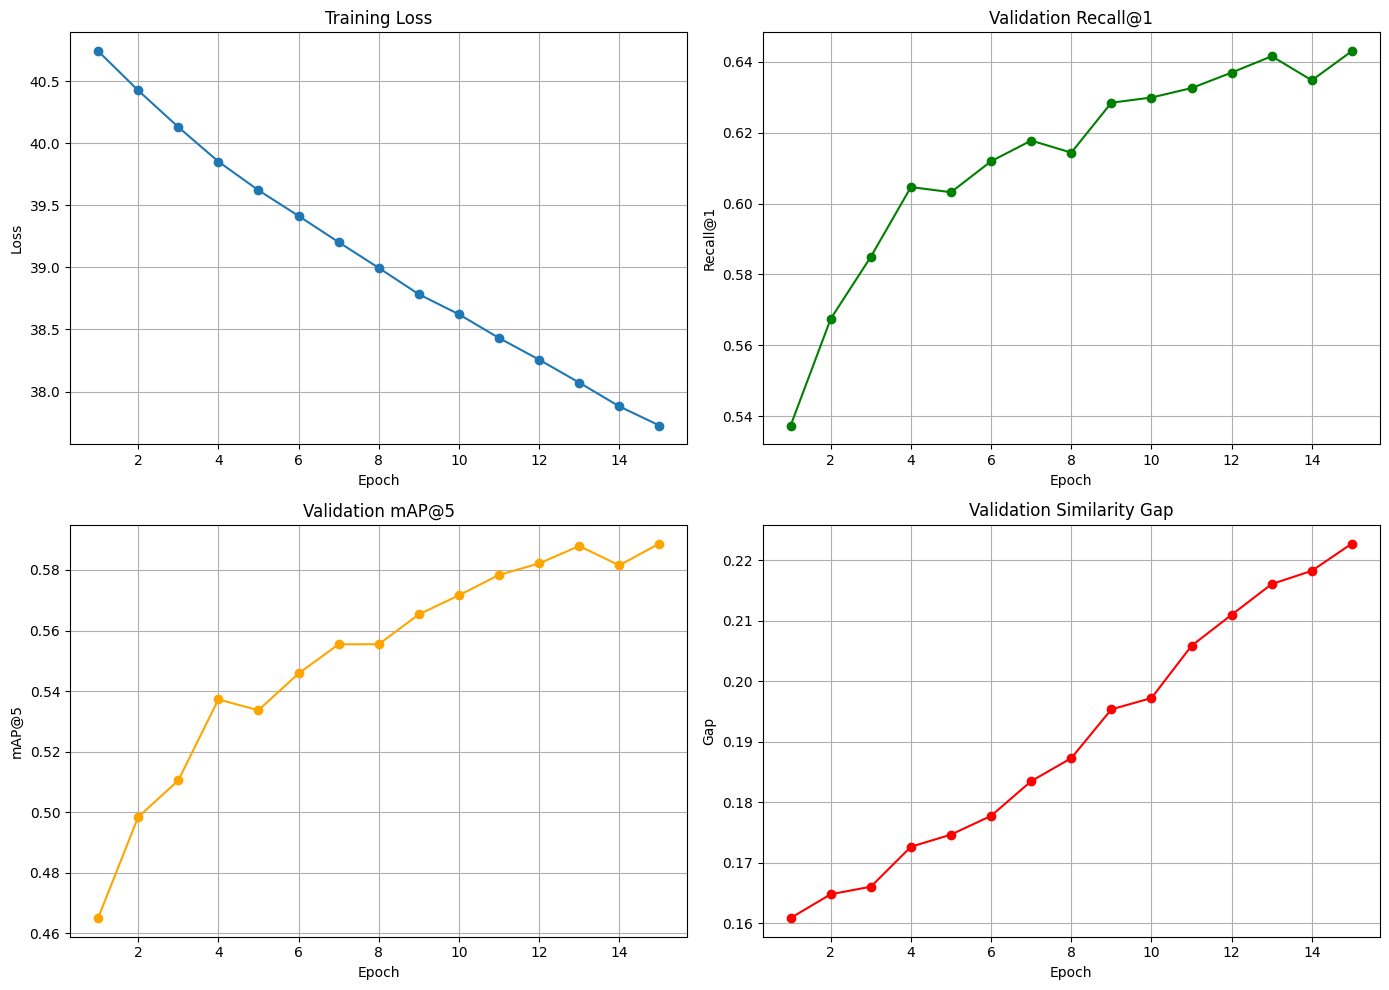

In [23]:
# ==================== Графики обучения ====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

axes[0].plot(history['epoch'], history['train_loss'], marker='o', label='Train Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True)

axes[1].plot(history['epoch'], history['val_recall1'], marker='o', color='green', label='Recall@1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Recall@1')
axes[1].set_title('Validation Recall@1')
axes[1].grid(True)

axes[2].plot(history['epoch'], history['val_map5'], marker='o', color='orange', label='mAP@5')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('mAP@5')
axes[2].set_title('Validation mAP@5')
axes[2].grid(True)

axes[3].plot(history['epoch'], history['val_gap'], marker='o', color='red', label='Similarity Gap')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('Gap')
axes[3].set_title('Validation Similarity Gap')
axes[3].grid(True)

plt.tight_layout()
plt.show()

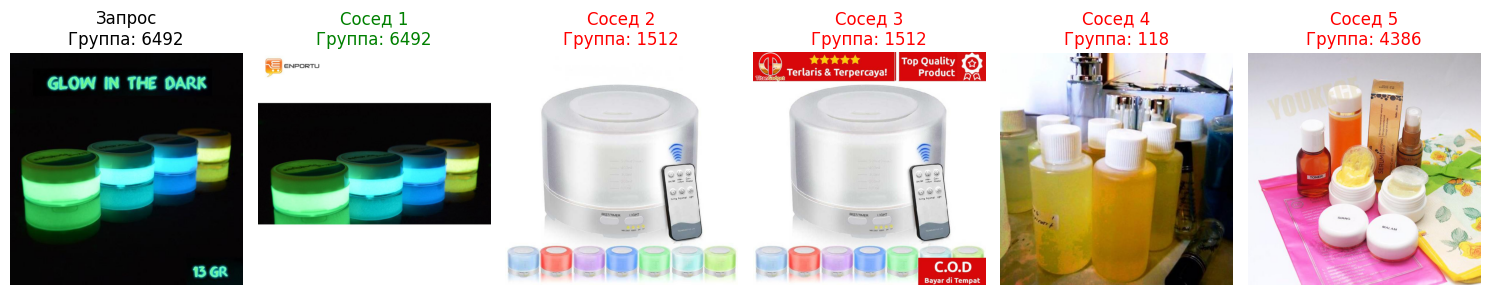

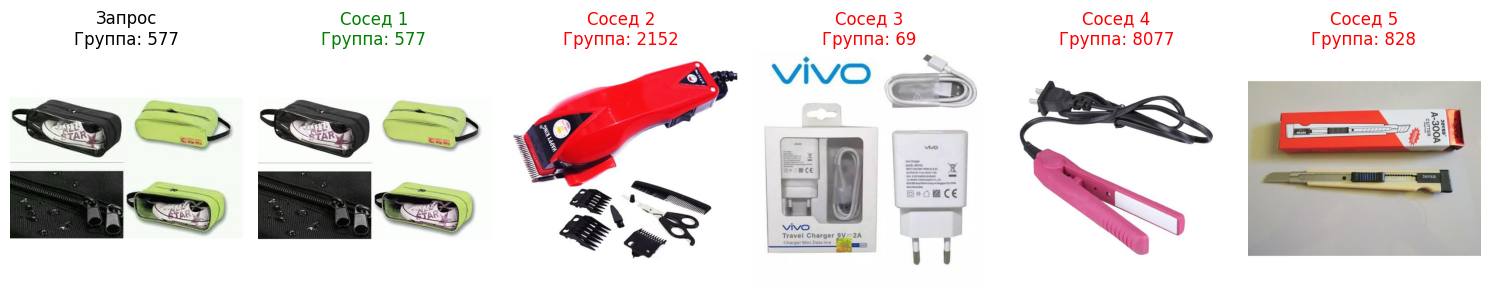

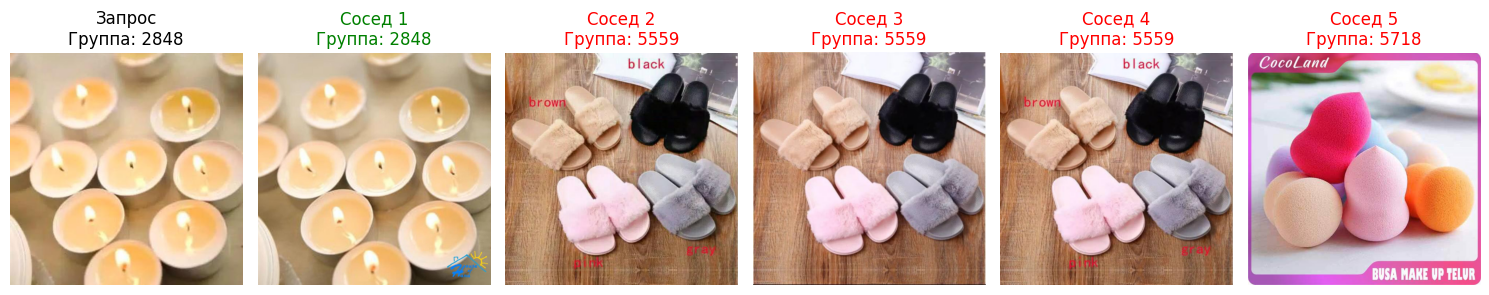

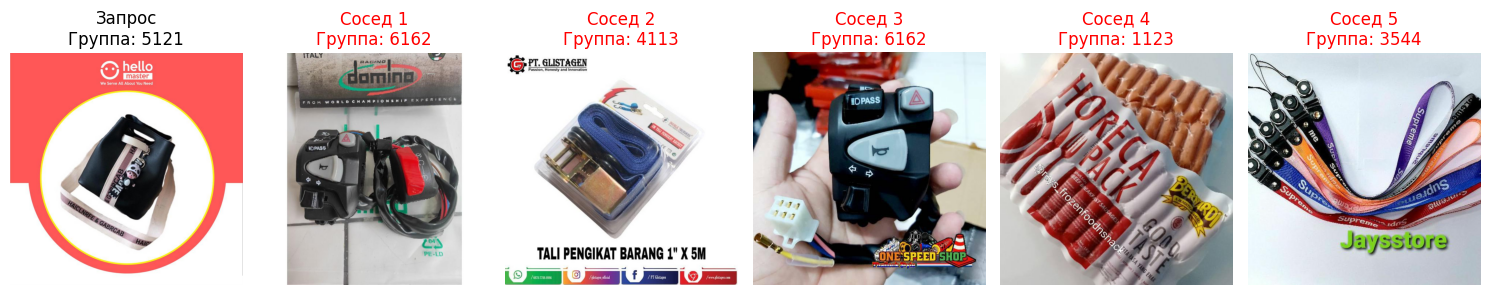

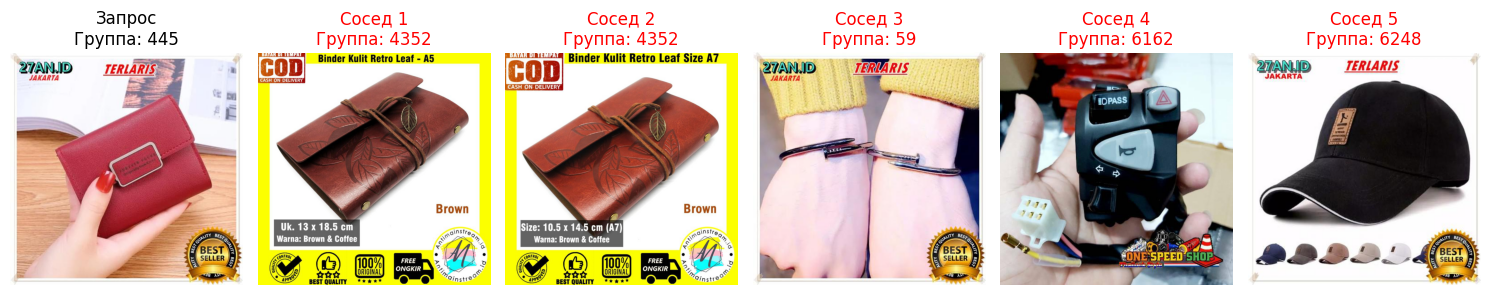

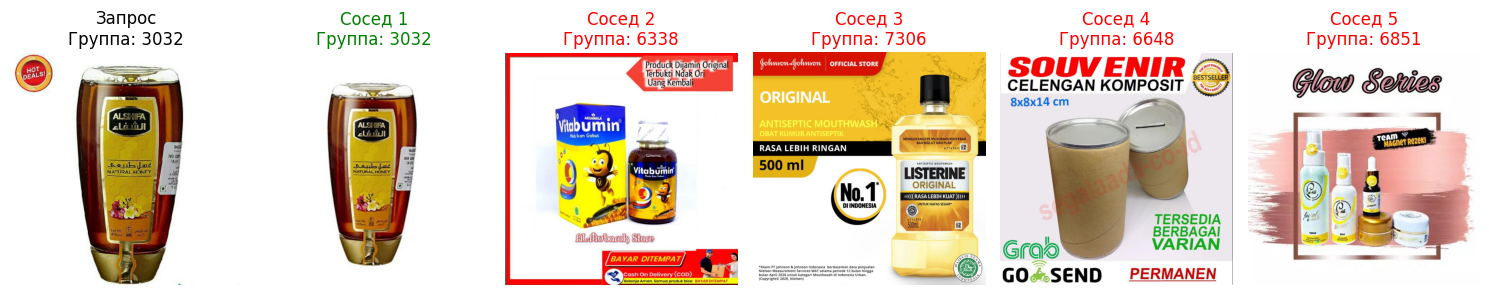

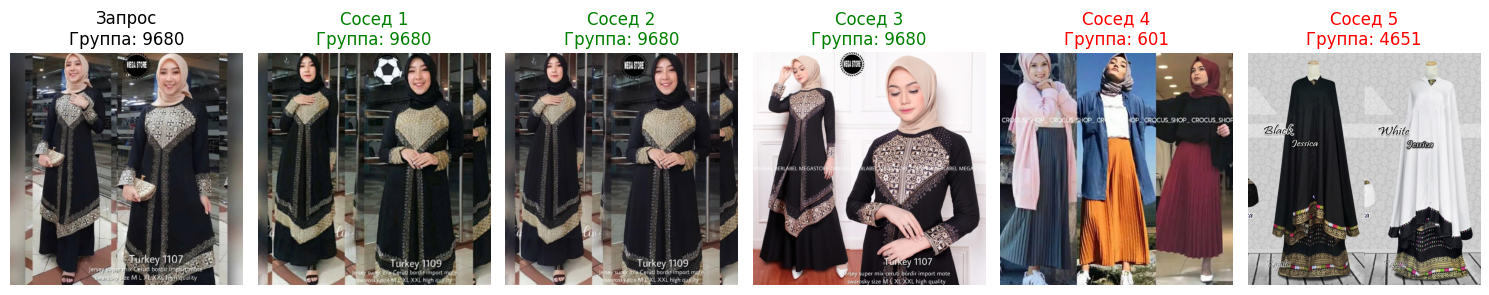

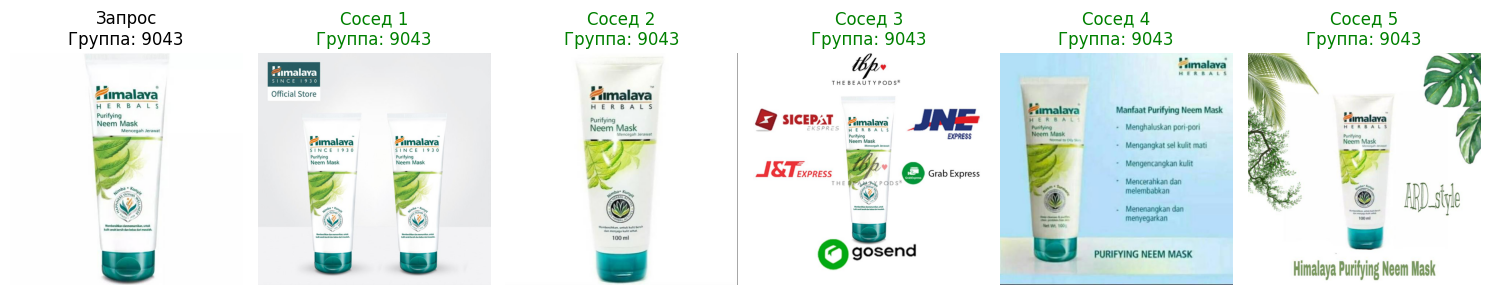

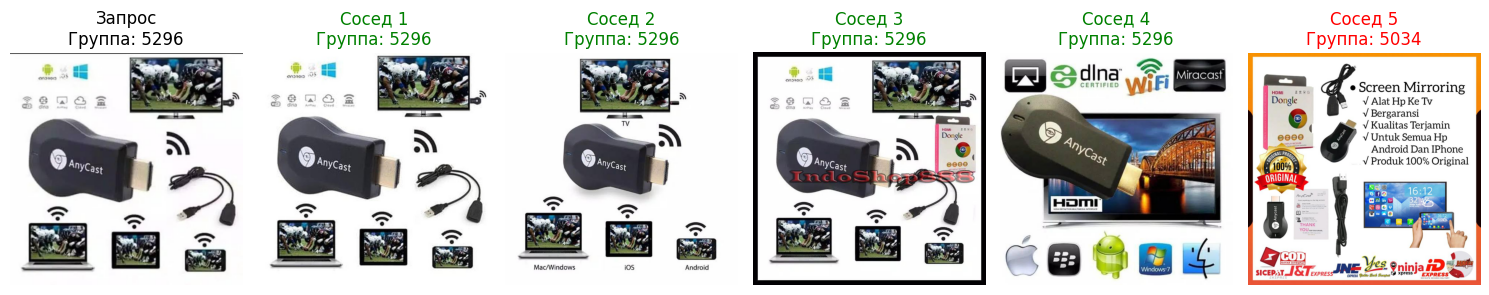

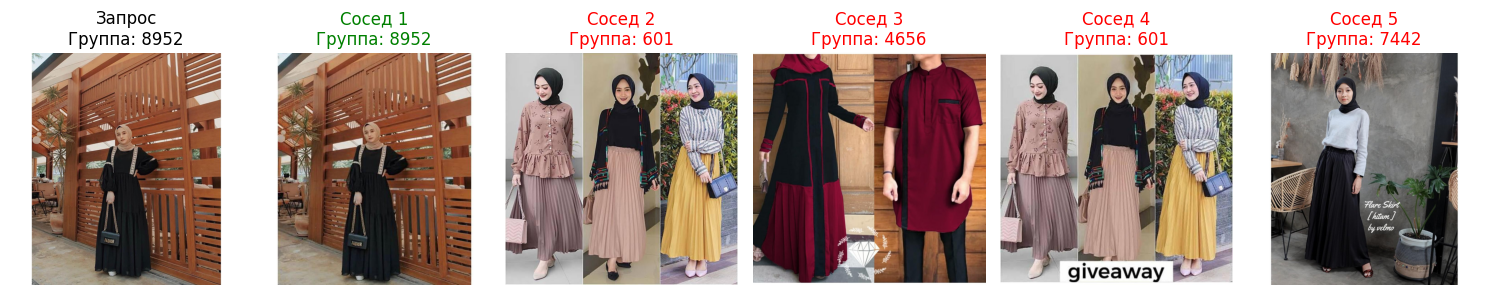

In [24]:
# Строим FAISS индекс для теста
faiss_index = faiss.IndexFlatIP(test_embs.shape[1])
faiss_index.add(test_embs)

# Показываем несколько случайных примеров поиска
for _ in range(10):
    idx = random.randint(0, len(test_df)-1)
    show_results(idx, test_df, test_embs, test_labels, faiss_index)

In [25]:
# Сохраняем FAISS индекс и пути
faiss.write_index(faiss_index, "baseline_index.faiss")
test_df[['image', 'label_group', 'label']].to_csv("test_database.csv", index=False)
print("FAISS индекс и база сохранены.")

FAISS индекс и база сохранены.
